In [4]:
import os
import glob

import json
import numpy as np
import pandas as pd

from pathlib import Path
from typing import List, Tuple, Any, Optional
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor

from concurrent.futures import ProcessPoolExecutor, as_completed

In [5]:
# STORAGE_DIR = "Z:\\starcraft-vision\\"
STORAGE_DIR = "/mnt/nas/baecm/starcraft-vision/"

DATA_DIR = os.path.join(STORAGE_DIR, "data")
GROUND_TRUTH_DIR = os.path.join(DATA_DIR, "label", "dst")
PREDICTIONS_DIR = os.path.join(STORAGE_DIR, "predictions")

In [6]:
REPLAYS = [1725]
# REPLAYS = [36, 212, 438, 522, 1660, 6254]
# REPLAYS = [1559, 1628, 2351, 6219, 11251]
# REPLAYS = [275, 1725, 3613, 4520, 4664]
# REPLAYS = [36, 212, 438, 522, 1660, 6254, 1559, 1628, 2351, 6219, 11251, 275, 1725, 3613, 4520, 4664]

REPLAYS = [str(_) + '.rep' for _ in REPLAYS]

In [7]:
# TARGET_MODEL = "test_input_model/model_020"
# TARGET_MODEL = "all_correct_win4_b16_20250826_045543/model_030"
# TARGET_MODEL = "all_correct_win4_b16_kbrs_20250821_044349/model_015"

In [8]:
ground_truth_json_path = [
    f for name in REPLAYS
    for f in glob.glob(os.path.join(GROUND_TRUTH_DIR, name, '*.json'))
]

ground_truth_json_path

['/mnt/nas/baecm/starcraft-vision/data/label/dst/1725.rep/all_correct.json']

In [9]:
def _build_json_paths(directory: str,
                      label_method: str = "all_correct",
                      replays: Optional[List[str]] = None) -> List[str]:
    directory = os.path.abspath(directory)
    if replays:
        return [os.path.join(directory, rep, f"{label_method}.json") for rep in replays]
    return [str(p) for p in Path(directory).glob("**/*.json")]

def _read_one_json(path: str, use_orjson: bool = True) -> Tuple[str, Any, Optional[str]]:
    try:
        if use_orjson:
            try:
                import orjson
                with open(path, "rb") as f:
                    return path, orjson.loads(f.read()), None
            except ModuleNotFoundError:
                pass  # orjson이 없으면 표준 json로 폴백
        with open(path, "r", encoding="utf-8") as f:
            return path, json.load(f), None
    except Exception as e:
        return path, None, f"{type(e).__name__}: {e}"

def read_json_files_threaded(directory: str,
                             label_method: str = "all_correct",
                             replays: Optional[List[str]] = None,
                             max_workers: Optional[int] = None) -> List[Any]:
    paths = _build_json_paths(directory, label_method, replays)
    if not paths:
        return []

    if max_workers is None:
        cpu = os.cpu_count() or 4
        max_workers = min(32, cpu * 5)

    results: List[Any] = []
    errors: List[str] = []

    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        for path, data, err in ex.map(_read_one_json, paths):
            if err:
                errors.append(f"[FAIL] {path} -> {err}")
            else:
                results.append()

    if errors:
        print("\n".join(errors))
    return results

def read_json_files_processes(directory: str,
                              label_method: str = "all_correct",
                              replays: Optional[List[str]] = None,
                              max_workers: Optional[int] = None) -> List[Any]:
    paths = _build_json_paths(directory, label_method, replays)
    if not paths:
        return []

    if max_workers is None:
        max_workers = os.cpu_count() or 4

    results: List[Any] = []
    errors: List[str] = []

    with ProcessPoolExecutor(max_workers=max_workers) as ex:
        for path, data, err in ex.map(_read_one_json, paths):
            if err:
                errors.append(f"[FAIL] {path} -> {err}")
            else:
                results.append(data)

    if errors:
        print("\n".join(errors))
    return results

In [10]:
ground_truth_data = read_json_files_processes(GROUND_TRUTH_DIR, label_method='all_correct', replays=REPLAYS, max_workers=8)

In [11]:
def get_annotations(data, replay_suffix=".rep"):
    frames = []

    for item in (data or []):
        anns = item.get("annotations", [])
        if not anns:
            continue

        df = pd.DataFrame(anns)

        desc = (item.get("info") or {}).get("description", "") or ""
        replay_id = None
        if isinstance(desc, str) and desc.strip():
            replay_id = desc.strip().split()[-1]

        if replay_id is None:
            replay_id = "unknown"

        if replay_suffix and not str(replay_id).endswith(replay_suffix):
            replay_id = f"{replay_id}{replay_suffix}"

        df["replay"] = replay_id
        frames.append(df)

    base_cols = ["replay", "id", "image_id", "category_id", "bbox", "area", "segmentation", "iscrowd"]
    if not frames:
        return pd.DataFrame(columns=base_cols + ["score"])

    has_score = any("score" in f.columns for f in frames)

    wanted_cols = base_cols + (["score"] if has_score else [])
    for i, f in enumerate(frames):
        for col in wanted_cols:
            if col not in f.columns:
                frames[i][col] = pd.NA

    annotations = pd.concat(frames, ignore_index=True)

    return annotations[wanted_cols]

In [12]:
annotation_ground_truth = get_annotations(ground_truth_data)
# annotation_prediction = get_annotations(prediction_data)

In [13]:
# def dataframe_topk_score(dataframe, K=1):
#     topk_df = (
#       dataframe.sort_values('score', ascending=False)
#         .groupby(['replay', 'image_id'], group_keys=False)
#         .head(K)
#     )
#     return topk_df.sort_values(['replay', 'image_id'])

In [14]:
# top1_annotation_prediction = dataframe_topk_score(annotation_prediction, K=1)

In [15]:
annotation_ground_truth["hid"] = annotation_ground_truth.groupby(["replay", "image_id"]).cumcount()  # 0~4 인덱스 생성
wide_ground_truth = annotation_ground_truth.pivot(index=["replay", "image_id"], columns="hid", values="bbox")
wide_ground_truth.columns = [f"gt_{i}" for i in wide_ground_truth.columns]
wide_ground_truth.reset_index(inplace=True)


In [16]:
# wide_ground_truth

In [17]:
item = wide_ground_truth.iloc[17500]

In [18]:
item_npy = os.path.join(DATA_DIR, 'input', 'dst', item['replay'], str(item['image_id']) + '.npy')

In [19]:
from matplotlib import pyplot as plt

In [20]:
from enum import Enum

class Channel(Enum):
    Player_1_Worker = 0
    Player_1_Ground = 1
    Player_1_Air = 2
    Player_1_Building = 3
    
    Player_2_Worker = 4
    Player_2_Ground = 5
    Player_2_Air = 6
    Player_2_Building = 7
    
    Resource = 8
    Vision = 9
    Terrain = 10

In [21]:
item_obj = np.load(item_npy)

In [22]:
kw, kh = 20, 12
stride = 1

def score_density(x: np.ndarray) -> np.ndarray:
    _, H, W = x.shape
    
    x_sum = x.sum(axis=0, keepdims=True).astype(np.float32, copy=False)  # (N,H,W)
    x_sum = x_sum.reshape(H, W).astype(np.float32, copy=False)  # (H,W)

    ii = np.pad(x_sum, ((1,0),(1,0)), mode='constant')
    ii = ii.cumsum(axis=0).cumsum(axis=1)
    
    win_sum = (
        ii[kh:, kw:]    # bottom-right
        - ii[:-kh, kw:] # top-right
        - ii[kh:, :-kw] # bottom-left
        + ii[:-kh, :-kw]# top-left
    )
    
    den = win_sum / float(kh * kw)                       # (oh,ow)
    return den

In [23]:
# sample_density_p1 = score_density(item_obj[0:4,...])
# sample_density_p2 = score_density(item_obj[4:8,...])
# print(sample_density_p1.shape, sample_density_p2.shape)

# fig, axes = plt.subplots(1,2, figsize=(12, 6), sharex=True, sharey=True)

# axes[0].imshow(sample_density_p1)
# axes[1].imshow(sample_density_p2)

# plt.suptitle(f"{item['replay']} - {item['image_id']}")

# # plt.axis('off')
# plt.tight_layout()

# plt.show()

In [24]:
from numpy.lib.stride_tricks import sliding_window_view

def gaussian_kernel2d(kw, kh, sigma=None, dtype=np.float32):
    if sigma is None:
        sigma_y = max(kh, 1) / 3.0
        sigma_x = max(kw, 1) / 3.0
    elif np.isscalar(sigma):
        sigma_y = sigma_x = float(sigma)
    else:
        sigma_y, sigma_x = map(float, sigma)

    y = np.arange(kh, dtype=dtype) - (kh - 1) / 2.0
    x = np.arange(kw, dtype=dtype) - (kw - 1) / 2.0
    Y, X = np.meshgrid(y, x, indexing='ij')
    K = np.exp(-(Y**2)/(2*sigma_y**2) - (X**2)/(2*sigma_x**2)).astype(dtype, copy=False)
    K /= (K.sum() + 1e-6)
    return K  # (kh, kw), sum≈1


def score_centeredness(x: np.ndarray, stride=1, sigma=None) -> np.ndarray:
    _, H, W = x.shape
    
    x_sum = x.sum(axis=0, keepdims=True).astype(np.float32, copy=False)
    x_sum = x_sum.reshape(H, W).astype(np.float32, copy=False)  # (H,W)
    
    K = gaussian_kernel2d(kw, kh, sigma=sigma, dtype=np.float32)  # (kh, kw), sum=1
    denom = float(K.sum()) + 1e-6
    
    patches = sliding_window_view(x_sum, (kh, kw))                     # (N, H-kh+1, W-kw+1, kh, kw)

    out = (patches * K).sum(axis=(-1, -2))                                  # (N, H-kh+1, W-kw+1)
    
    # 평균 정규화 (PyTorch 경로와 동일)
    denom = float(K.sum()) + 1e-6
    out = out / denom

    # 입력 dtype 정책: 부동소수면 입력 dtype으로 반환, 정수 입력이면 float32 유지
    if x.dtype.kind == 'f':
        out = out.astype(x.dtype, copy=False)
    return out

In [25]:
# sample_centeredness_p1 = score_centeredness(item_obj[0:4,...])
# sample_centeredness_p2 = score_centeredness(item_obj[4:8,...])
# print(sample_centeredness_p1.shape, sample_centeredness_p2.shape)

# fig, axes = plt.subplots(1,2, figsize=(12, 6), sharex=True, sharey=True)

# axes[0].imshow(sample_centeredness_p1)
# axes[1].imshow(sample_centeredness_p2)

# plt.suptitle(f"{item['replay']} - {item['image_id']}")

# # plt.axis('off')
# plt.tight_layout()

# plt.show()


In [26]:
def get_projection(x: np.ndarray, axis: int, keepdims: bool = False) -> np.ndarray:
    """입력 배열 x에 대해 지정된 축(axis)을 따라 1차원 투영을 수행합니다.
    
    Args:
        x (np.ndarray): 입력 배열.
        axis (int): 투영을 수행할 축. 0은 높이, 1은 너비를 나타냅니다.
        keepdims (bool): True로 설정하면 투영 후에도 차원 수를 유지합니다. 기본값은 False입니다.
    
    Returns:
        np.ndarray: 투영된 배열.
    """
    if axis not in (0, 1):
        raise ValueError("axis는 0(높이) 또는 1(너비)이어야 합니다.")
    
    # 축을 따라 합산하여 투영 수행
    projection = x.sum(axis=0 if axis == 0 else 1, keepdims=keepdims)
    
    return projection

In [27]:
def score_mixture(x: np.ndarray, stride=1, mode='entropy') -> np.ndarray:
    _, H, W = x.shape
    eps = 1e-6
    pow_k = 1.0  # 0.5, 1.0, 2.0
    
    # ONES = np.ones((kh, kw), dtype=np.float32)
    xA = x[0:4,...].sum(axis=0, keepdims=False).astype(np.float32, copy=False)  # (H,W)
    xB = x[4:8,...].sum(axis=0, keepdims=False).astype(np.float32, copy=False)  # (H,W)
    
    def _sum_pool2d(x1):
        ii = np.pad(x1, ((1,0),(1,0)), mode='constant')
        ii = ii.cumsum(axis=0).cumsum(axis=1)
        
        win_sum = (
            ii[kh:, kw:]    # bottom-right
            - ii[:-kh, kw:] # top-right
            - ii[kh:, :-kw] # bottom-left
            + ii[:-kh, :-kw]# top-left
        )
        return win_sum
    
    A = _sum_pool2d(xA)  # (oh,ow)
    B = _sum_pool2d(xB)  # (oh,ow)
    
    den = np.maximum(A + B, eps, dtype=np.float32)                       # (oh,ow)
    p = A / den  # (oh,ow)
    
    if mode == 'entropy':
        p1 = np.clip(p, eps, 1.0 - eps)
        q1 = np.clip(1.0 - p, eps, 1.0 - eps)
        
        conf = -(p1 * np.log(p1) + q1 * np.log(q1)) / np.log(2.0)  # (oh,ow), [0,1]
    elif mode == 'gini':
        conf = 2.0 * p * (1.0 - p)  # (oh,ow), [0,0.5]
    elif mode == 'linear':
        conf = 1.0 - np.abs(2.0 * p - 1.0)  # (oh,ow), [0,1]
    else:
        conf = 4.0 * p * (1.0 - p)  # (oh,ow), [0,1]
        
    if pow_k != 1.0:
        conf = np.clip(conf, 0.0, 1.0) ** pow_k  # (oh,ow), [0,1]
        
    return conf, A, B

In [28]:
# conf, Ao, Bo = score_mixture(item_obj, mode='linear')
# print(conf.shape, Ao.shape, Bo.shape)

# fig, axes = plt.subplots(1,3, figsize=(18, 6), sharex=True, sharey=True)

# axes[0].imshow(conf)
# axes[1].imshow(Ao)
# axes[2].imshow(Bo)

# plt.suptitle(f"{item['replay']} - {item['image_id']}")

# plt.tight_layout()

# plt.show()

In [35]:
def overview(ax, x: np.ndarray):
    # Terrain & resource
    ax.imshow(x[Channel.Terrain.value] > 0, cmap='Greys', alpha=0.5)
    resource_alpha = np.where(x[Channel.Resource.value] == 1, 1.0, 0.0)
    ax.imshow(x[Channel.Resource.value] == 1, cmap='BuGn', alpha=resource_alpha)
    
    # Player colors
    p1_cmap = 'Greens'
    p2_cmap = 'Reds'
    
    # Player 1 & 2 - worker
    player_1_worker_alpha = np.where(x[Channel.Player_1_Worker.value] != 0, 1.0, 0.0)
    player_2_worker_alpha = np.where(x[Channel.Player_2_Worker.value] != 0, 1.0, 0.0)
    ax.imshow(x[Channel.Player_1_Worker.value] != 0, cmap=p1_cmap, alpha=player_1_worker_alpha)
    ax.imshow(x[Channel.Player_2_Worker.value] != 0, cmap=p2_cmap, alpha=player_2_worker_alpha)
    
    # Player 1 & 2 - ground
    player_1_ground_alpha = np.where(x[Channel.Player_1_Ground.value] != 0, 1.0, 0.0)
    player_2_ground_alpha = np.where(x[Channel.Player_2_Ground.value] != 0, 1.0, 0.0)
    ax.imshow(x[Channel.Player_1_Ground.value] != 0, cmap=p1_cmap, alpha=player_1_ground_alpha)
    ax.imshow(x[Channel.Player_2_Ground.value] != 0, cmap=p2_cmap, alpha=player_2_ground_alpha)
    
    # Player 1 & 2 - air
    player_1_air_alpha = np.where(x[Channel.Player_1_Air.value] != 0, 1.0, 0.0)
    player_2_air_alpha = np.where(x[Channel.Player_2_Air.value] != 0, 1.0, 0.0)
    ax.imshow(x[Channel.Player_1_Air.value] != 0, cmap=p1_cmap, alpha=player_1_air_alpha)
    ax.imshow(x[Channel.Player_2_Air.value] != 0, cmap=p2_cmap, alpha=player_2_air_alpha)

    # Player 1 & 2 - building
    player_1_building_alpha = np.where(x[Channel.Player_1_Building.value] != 0, 1.0, 0.0)
    player_2_building_alpha = np.where(x[Channel.Player_2_Building.value] != 0, 1.0, 0.0)
    ax.imshow(x[Channel.Player_1_Building.value] != 0, cmap=p1_cmap, alpha=player_1_building_alpha)
    ax.imshow(x[Channel.Player_2_Building.value] != 0, cmap=p2_cmap, alpha=player_2_building_alpha)

    # Vision mask
    vision_alpha = np.where(x[Channel.Vision.value] == 1, 0.0, 0.9)
    ax.imshow(np.zeros_like(x[Channel.Vision.value]), cmap='Greys_r', alpha=vision_alpha)

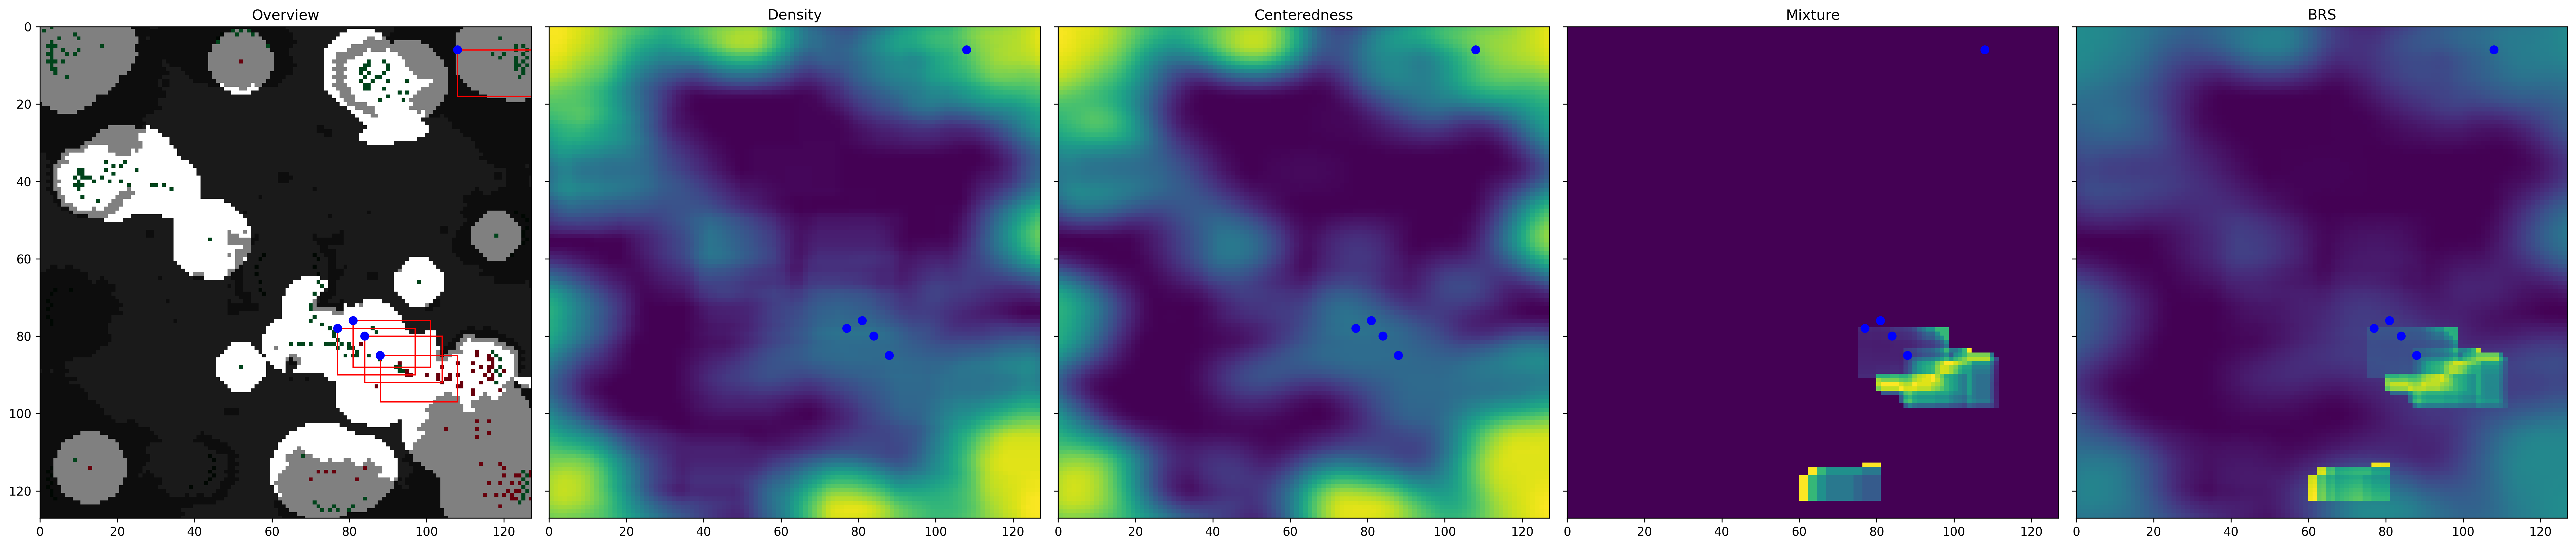

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, axes = plt.subplots(1, 5, figsize=(30, 6), sharex=True, sharey=True, dpi=300)

# 0) 개요
overview(axes[0], item_obj)
axes[0].set_title('Overview')

# 1) 스코어 맵
density = score_density(item_obj)          # (oh, ow)
centeredness = score_centeredness(item_obj)# (oh, ow)
mixture, _, _ = score_mixture(item_obj, mode='linear')  # (oh, ow)

# heatmap은 0~128 좌표계로 매핑
axes[1].imshow(density, origin='lower', extent=(0, 128, 0, 128))
axes[1].set_title('Density')
axes[2].imshow(centeredness, origin='lower', extent=(0, 128, 0, 128))
axes[2].set_title('Centeredness')
axes[3].imshow(mixture, origin='lower', extent=(0, 128, 0, 128))
axes[3].set_title('Mixture')
axes[4].imshow(0.3 * density + 3.0 * mixture + 0.3 * centeredness, origin='lower', extent=(0, 128, 0, 128))
axes[4].set_title('BRS')

# 2) 축/비율 정리 (imshow 이후에 설정하는 게 안전)
for ax in axes:
    ax.set_xlim(0, 128 - 1)
    ax.set_ylim(128 - 1, 0)
    ax.set_aspect('equal')  # 원이 찌그러지지 않게

# 3) GT 오버레이
for gt in item[['gt_0', 'gt_1', 'gt_2', 'gt_3', 'gt_4']]:
    if gt is None or len(gt) != 4:
        continue
    x, y, w, h = map(float, gt)

    # a) 박스는 axes[0]에
    rect = patches.Rectangle((x, y), w, h,
                             linewidth=1, edgecolor='red',
                             linestyle='-', facecolor='none')
    axes[0].add_patch(rect)

    # b) 점은 각 축마다 "새" Circle 생성
    for ax in (axes[0], axes[1], axes[2], axes[3], axes[4]):
        ax.add_patch(patches.Circle((x, y), radius=1.0, color='blue'))

plt.tight_layout()
plt.show()